In [1]:
!pip install seaborn


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: C:\Users\Narayani G\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

import joblib

In [3]:
df = pd.read_csv("student-por.csv")

df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13


In [4]:
print("Shape of Dataset:")
print(df.shape)

print("\nColumns:")
print(df.columns)

print("\nDataset Information:")
print(df.info())

print("\nStatistical Summary:")
print(df.describe())


Shape of Dataset:
(649, 33)

Columns:
Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='str')

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      649 non-null    str  
 1   sex         649 non-null    str  
 2   age         649 non-null    int64
 3   address     649 non-null    str  
 4   famsize     649 non-null    str  
 5   Pstatus     649 non-null    str  
 6   Medu        649 non-null    int64
 7   Fedu        649 non-null    int64
 8   Mjob        649 non-null    str  
 9   Fjob        649 non-null    st

In [5]:
print(df.isnull().sum())

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64


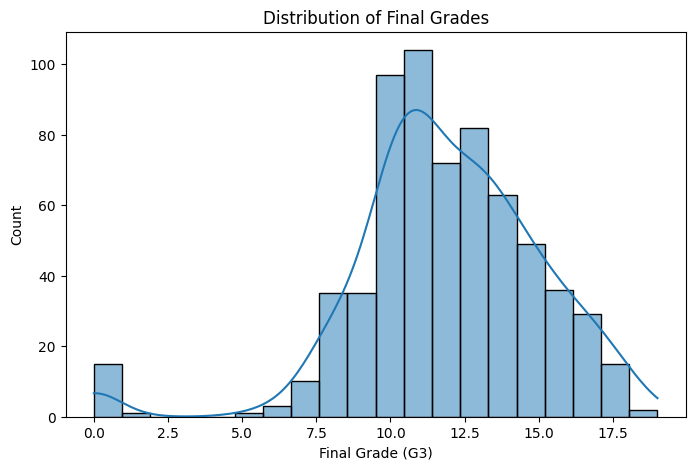

In [6]:
plt.figure(figsize=(8,5))

sns.histplot(df["G3"], bins=20, kde=True)

plt.title("Distribution of Final Grades")
plt.xlabel("Final Grade (G3)")
plt.ylabel("Count")
plt.savefig("grade_distribution.png", bbox_inches="tight")
plt.show()

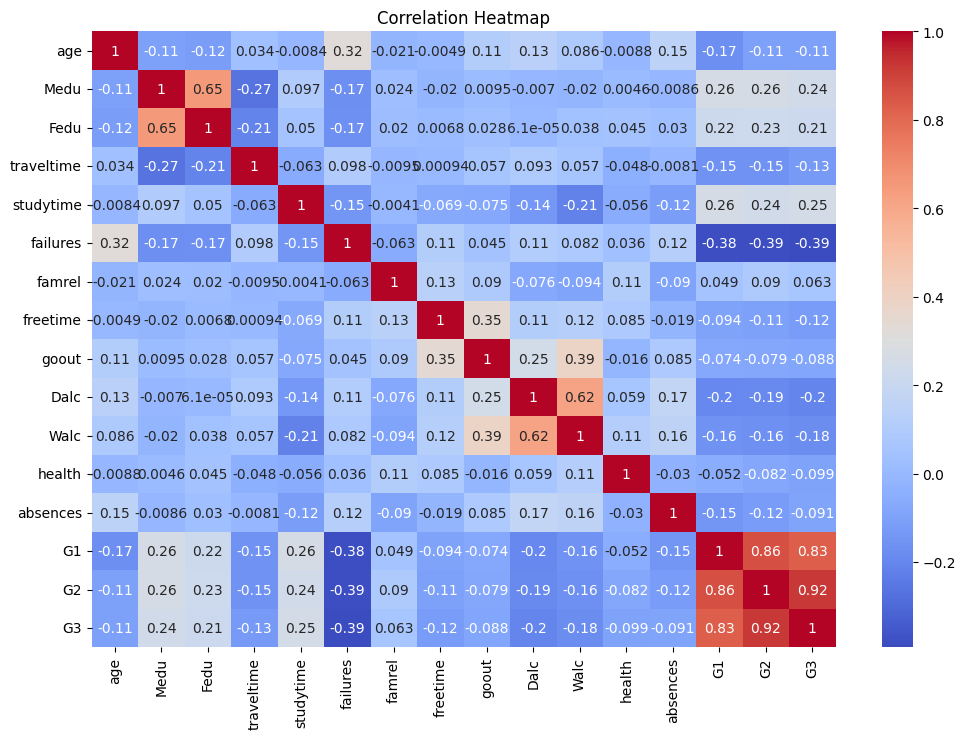

In [7]:
plt.figure(figsize=(12,8))

numeric_df = df.select_dtypes(include=['int64'])

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.savefig("heatmap.png", bbox_inches="tight")
plt.show()

In [8]:
df = pd.get_dummies(
    df,
    drop_first=True
)

print(df.shape)

(649, 42)


In [9]:
X = df.drop("G3", axis=1)

y = df["G3"]

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [11]:
lr_model = LinearRegression()

lr_model.fit(
    X_train,
    y_train
)

lr_predictions = lr_model.predict(X_test)

In [12]:
lr_mae = mean_absolute_error(
    y_test,
    lr_predictions
)

lr_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        lr_predictions
    )
)

lr_r2 = r2_score(
    y_test,
    lr_predictions
)

print("Linear Regression Results")
print("-------------------------")

print("MAE :", lr_mae)
print("RMSE:", lr_rmse)
print("R2  :", lr_r2)

Linear Regression Results
-------------------------
MAE : 0.7650597682758264
RMSE: 1.2148700573987048
R2  : 0.8486513286537314


In [13]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf_model.fit(
    X_train,
    y_train
)

rf_predictions = rf_model.predict(X_test)

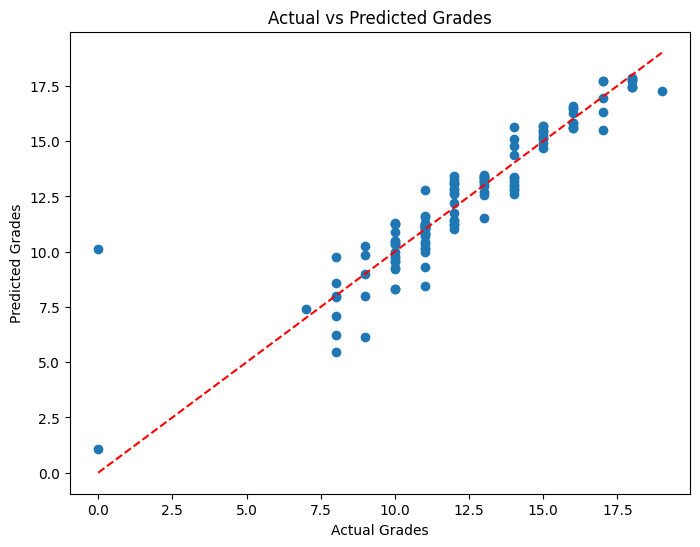

In [14]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, rf_predictions)

plt.xlabel("Actual Grades")
plt.ylabel("Predicted Grades")

plt.title("Actual vs Predicted Grades")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.show()

In [15]:
rf_mae = mean_absolute_error(
    y_test,
    rf_predictions
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_predictions
    )
)

rf_r2 = r2_score(
    y_test,
    rf_predictions
)

print("Random Forest Results")
print("--------------------")

print("MAE :", rf_mae)
print("RMSE:", rf_rmse)
print("R2  :", rf_r2)

Random Forest Results
--------------------
MAE : 0.7367692307692307
RMSE: 1.235617254654531
R2  : 0.8434378109754618


In [16]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest"
    ],
    "MAE": [
        lr_mae,
        rf_mae
    ],
    "RMSE": [
        lr_rmse,
        rf_rmse
    ],
    "R2 Score": [
        lr_r2,
        rf_r2
    ]
})

print(results)

               Model       MAE      RMSE  R2 Score
0  Linear Regression  0.765060  1.214870  0.848651
1      Random Forest  0.736769  1.235617  0.843438


In [17]:
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

print(importance_df.head(10))

      Feature  Importance
14         G2    0.827750
12   absences    0.035207
13         G1    0.018652
0         age    0.008780
7    freetime    0.007537
9        Dalc    0.007343
1        Medu    0.006484
6      famrel    0.006302
15  school_MS    0.006217
8       goout    0.005875


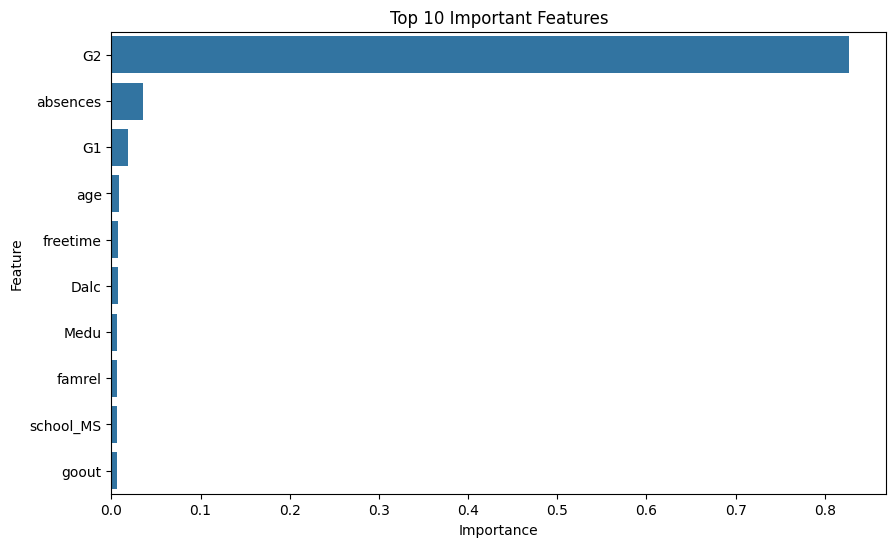

In [18]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance_df.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Important Features")
plt.savefig("feature_importance.png", bbox_inches="tight")
plt.show()

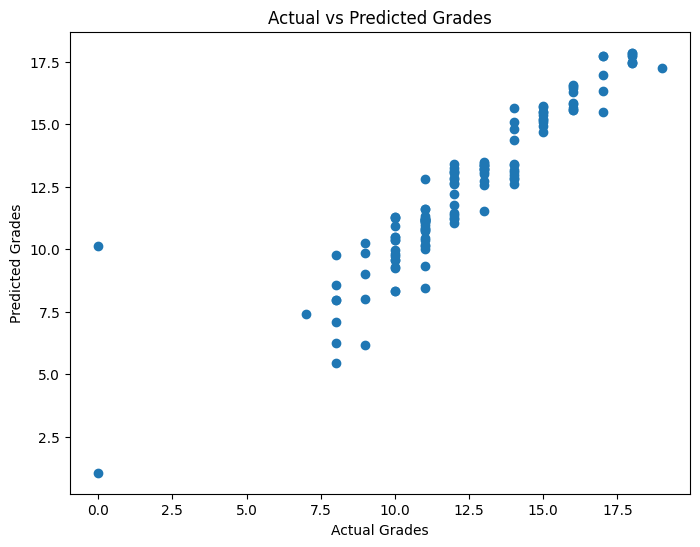

In [19]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    rf_predictions
)

plt.xlabel("Actual Grades")
plt.ylabel("Predicted Grades")

plt.title("Actual vs Predicted Grades")

plt.show()

In [20]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    rf_model,
    X,
    y,
    cv=5,
    scoring='r2'
)

print("Cross Validation R2 Scores:")
print(scores)

print("Average R2:", scores.mean())

Cross Validation R2 Scores:
[0.75210021 0.69919307 0.82559571 0.83068125 0.79031055]
Average R2: 0.7795761567134092


In [21]:
joblib.dump(
    rf_model,
    "student_performance_model.pkl"
)

print("Model Saved Successfully!")

Model Saved Successfully!


In [22]:
sample_student = X.iloc[[0]]

prediction = rf_model.predict(
    sample_student
)

print("Predicted Grade:", prediction[0])

Predicted Grade: 10.895
